<a href="https://colab.research.google.com/github/tehreem-zubair-S/DS-AI-Learning-Journey/blob/main/iqra_logistics.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


  IQRA LOGISTICS PVT LTD - OPTIMIZER
1. Display City Delivery Nodes
2. Plan Optimized Trip (Standard)
3. Plan Trip with Priority Locations
4. Run Performance Simulation
5. Exit

Select Option: 1


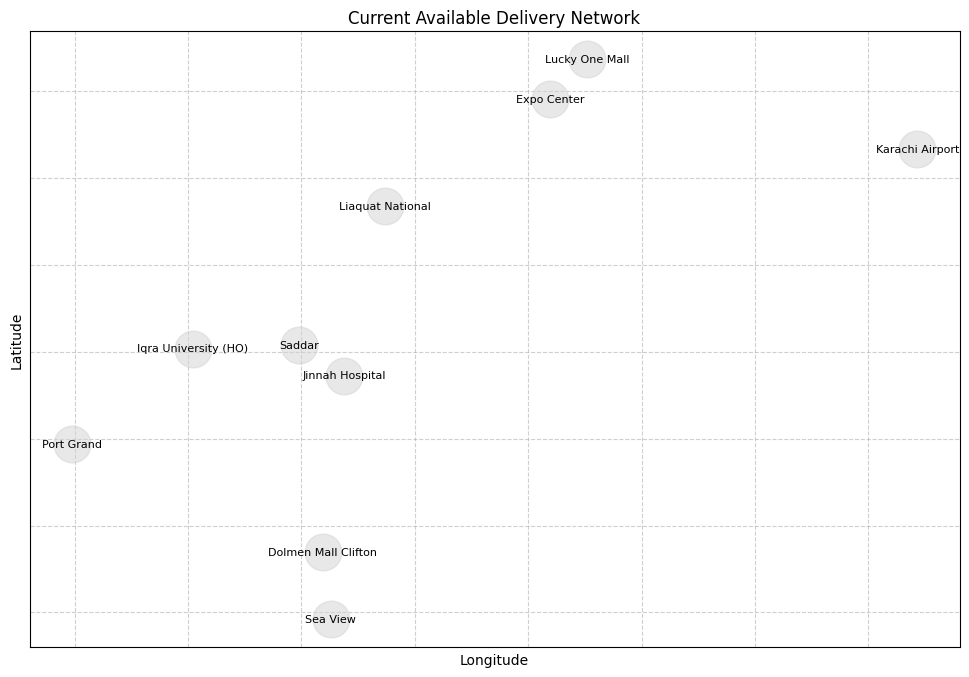


  IQRA LOGISTICS PVT LTD - OPTIMIZER
1. Display City Delivery Nodes
2. Plan Optimized Trip (Standard)
3. Plan Trip with Priority Locations
4. Run Performance Simulation
5. Exit

Select Option: 2

Available locations: Iqra University (HO), Dolmen Mall Clifton, Jinnah Hospital, Karachi Airport, Port Grand, Liaquat National, Expo Center, Sea View, Lucky One Mall, Saddar
Enter delivery points (comma separated): Port Grand, Jinnah Hospital, Sea View, Expo Center, Saddar, Liaquat National

Optimal Route: Iqra University (HO) -> Port Grand -> Sea View -> Jinnah Hospital -> Saddar -> Expo Center -> Liaquat National -> Iqra University (HO)
Total Distance: 37.03 KM


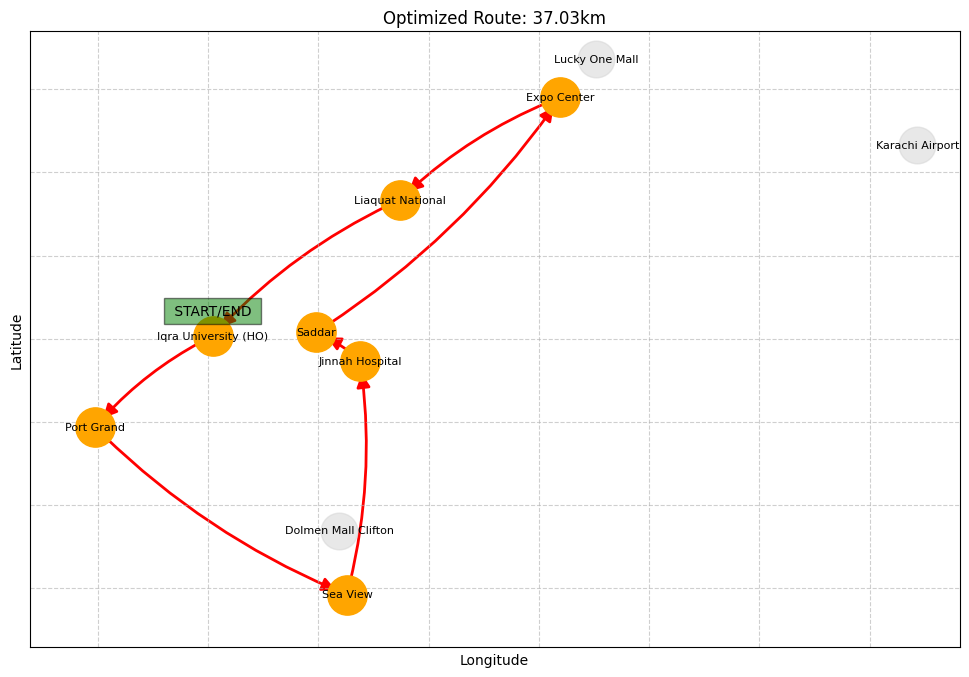


  IQRA LOGISTICS PVT LTD - OPTIMIZER
1. Display City Delivery Nodes
2. Plan Optimized Trip (Standard)
3. Plan Trip with Priority Locations
4. Run Performance Simulation
5. Exit

Select Option: 3

Enter Priority Deliveries (High Priority first, comma separated):
Locations: Liaquat National Hospital, Saddar, Karachi Airport, Port Grand, Expo Center, Dolmen Mall Clifton, Lucky One Mall

Priority Route: Iqra University (HO) -> Saddar -> Karachi Airport -> Port Grand -> Expo Center -> Dolmen Mall Clifton -> Lucky One Mall -> Liaquat National -> Jinnah Hospital -> Sea View -> Iqra University (HO)
Total Distance: 101.64 KM


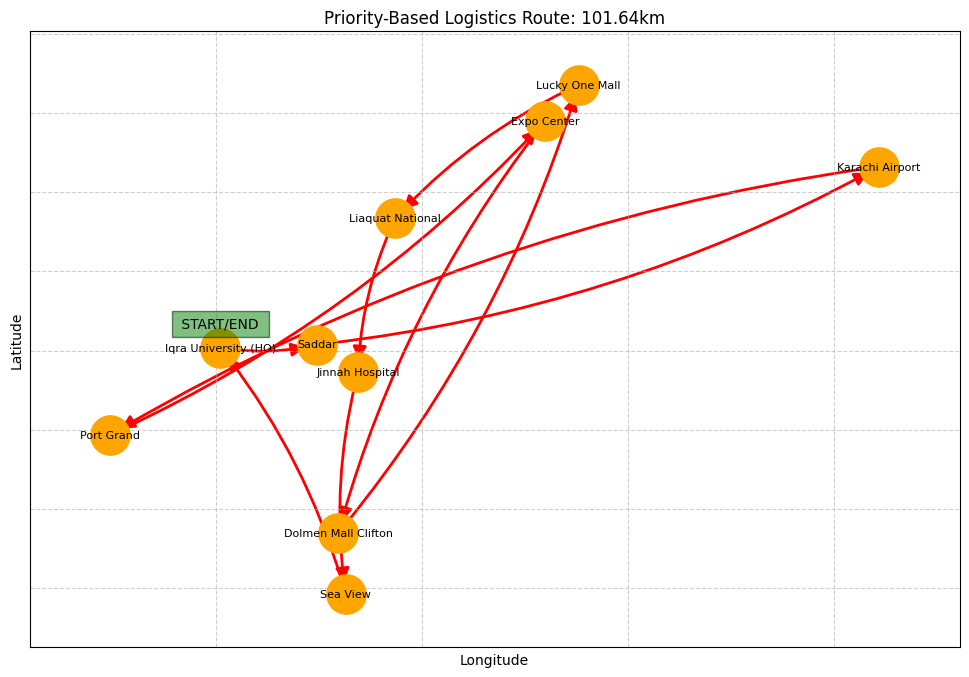


  IQRA LOGISTICS PVT LTD - OPTIMIZER
1. Display City Delivery Nodes
2. Plan Optimized Trip (Standard)
3. Plan Trip with Priority Locations
4. Run Performance Simulation
5. Exit

Select Option: 4

--- Simulation Report ---
Algorithm: Christofides (Metric TSP Approximation)
Time Complexity: O(V^3)
Performance Bound: ≤ 1.5 * Optimal
Status: VALIDATED for Polynomial Time Execution

  IQRA LOGISTICS PVT LTD - OPTIMIZER
1. Display City Delivery Nodes
2. Plan Optimized Trip (Standard)
3. Plan Trip with Priority Locations
4. Run Performance Simulation
5. Exit

Select Option: 5
Exiting System...


In [ ]:
import networkx as nx
import matplotlib.pyplot as plt
from geopy.distance import geodesic
from networkx.algorithms import matching

class IqraLogisticsPlanner:
    def __init__(self):
        # Realistic Karachi Coordinates
        self.locations = {
            'Iqra University (HO)': (24.8607, 67.0011),
            'Dolmen Mall Clifton': (24.8138, 67.0297),
            'Jinnah Hospital': (24.8545, 67.0345),
            'Karachi Airport': (24.9065, 67.1608),
            'Port Grand': (24.8387, 66.9744),
            'Liaquat National': (24.8934, 67.0435),
            'Expo Center': (24.9181, 67.0799),
            'Sea View': (24.7984, 67.0315),
            'Lucky One Mall': (24.9272, 67.0880),
            'Saddar': (24.8615, 67.0245),
        }
        self.full_graph = self._build_complete_graph()

    def _build_complete_graph(self):
        """Constructs a weighted graph where edges are actual distances."""
        G = nx.Graph()
        nodes = list(self.locations.keys())
        for i in range(len(nodes)):
            for j in range(i + 1, len(nodes)):
                loc1, loc2 = nodes[i], nodes[j]
                dist = geodesic(self.locations[loc1], self.locations[loc2]).km
                G.add_edge(loc1, loc2, weight=dist)
        return G

    def get_approx_optimal_tour(self, selected_nodes):
        """
        Implementation of Christofides Algorithm
        Complexity: O(n^3) - Polynomial Time
        Approximation Ratio: 1.5x of Optimal
        """
        if not selected_nodes:
            return [], 0.0

        if len(selected_nodes) == 1:
            return [selected_nodes[0], selected_nodes[0]], 0.0

        subgraph = self.full_graph.subgraph(selected_nodes)


        mst = nx.minimum_spanning_tree(subgraph, weight='weight')


        odd_degree_nodes = [v for v, d in mst.degree() if d % 2 == 1]


        matching_edges = set()
        if odd_degree_nodes:
            odd_subgraph = self.full_graph.subgraph(odd_degree_nodes)
            matching_edges = matching.min_weight_matching(odd_subgraph, weight='weight')


        multigraph = nx.MultiGraph(mst)

        multigraph.add_edges_from((u, v, subgraph[u][v]['weight']) for u, v in matching_edges)

        euler_circuit = list(nx.eulerian_circuit(multigraph, source=selected_nodes[0]))

        tour = []
        visited = set()
        for u, v in euler_circuit:
            if u not in visited:
                tour.append(u)
                visited.add(u)
        tour.append(tour[0])

        total_dist = sum(self.full_graph[tour[i]][tour[i+1]]['weight'] for i in range(len(tour)-1))
        return tour, total_dist

    def visualize(self, tour=None, title="Logistics Route Map"):
        plt.figure(figsize=(12, 8))

        pos = {name: (coords[1], coords[0]) for name, coords in self.locations.items()}


        nx.draw_networkx_nodes(self.full_graph, pos, node_size=700, node_color='lightgray', alpha=0.5)
        nx.draw_networkx_labels(self.full_graph, pos, font_size=8)

        if tour:

            tour_edges = [(tour[i], tour[i+1]) for i in range(len(tour)-1)]
            path_graph = nx.DiGraph()
            path_graph.add_edges_from(tour_edges)

            nx.draw_networkx_nodes(path_graph, pos, node_size=800, node_color='orange')
            nx.draw_networkx_edges(path_graph, pos, edgelist=tour_edges,
                                   edge_color='red', width=2, arrowsize=20, connectionstyle='arc3,rad=0.1')


            plt.text(pos[tour[0]][0], pos[tour[0]][1]+0.005, " START/END ",
                     bbox=dict(facecolor='green', alpha=0.5), horizontalalignment='center')

        plt.title(title)
        plt.xlabel("Longitude")
        plt.ylabel("Latitude")
        plt.grid(True, linestyle='--', alpha=0.6)
        plt.show()

        plt.show(block=False)
        plt.pause(4)
        plt.close()

def main_menu():
    planner = IqraLogisticsPlanner()

    while True:
        print("\n" + "="*40)
        print("  IQRA LOGISTICS PVT LTD - OPTIMIZER")
        print("="*40)
        print("1. Display City Delivery Nodes")
        print("2. Plan Optimized Trip (Standard)")
        print("3. Plan Trip with Priority Locations")
        print("4. Run Performance Simulation")
        print("5. Exit")

        choice = input("\nSelect Option: ")

        if choice == '1':
            planner.visualize(title="Current Available Delivery Network")

        elif choice == '2':
            print("\nAvailable locations:", ", ".join(planner.locations.keys()))
            targets = input("Enter delivery points (comma separated): ").split(",")
            targets = [t.strip() for t in targets if t.strip() in planner.locations]

            if not targets:
                print("No valid locations selected!")
                continue

            tour, dist = planner.get_approx_optimal_tour(['Iqra University (HO)'] + targets)
            print(f"\nOptimal Route: {' -> '.join(tour)}")
            print(f"Total Distance: {dist:.2f} KM")
            planner.visualize(tour, title=f"Optimized Route: {dist:.2f}km")

        elif choice == '3':
            # Priority logic: Visit high priority first, then optimize the rest
            print("\nEnter Priority Deliveries (High Priority first, comma separated):")
            prio_input = input("Locations: ").split(",")
            prio = [t.strip() for t in prio_input if t.strip() in planner.locations]

            if not prio:
                print("No valid priority locations selected. Optimizing for all non-HO locations if any.")
                all_non_ho = [loc for loc in planner.locations if loc != 'Iqra University (HO)']
                if not all_non_ho:
                    print("No other locations to visit besides Iqra University (HO).")
                    continue

                full_tour_nodes = ['Iqra University (HO)'] + all_non_ho
                tour, dist = planner.get_approx_optimal_tour(full_tour_nodes)
                print(f"\nOptimal Route (All Locations): {' -> '.join(tour)}")
                print(f"Total Distance: {dist:.2f} KM")
                planner.visualize(tour, title=f"Optimized Route (All Locations): {dist:.2f}km")
                continue

            current_tour_nodes = ['Iqra University (HO)'] + prio

            remaining_nodes = [loc for loc in planner.locations if loc not in prio and loc != 'Iqra University (HO)']

            if remaining_nodes:

                subproblem_nodes = [current_tour_nodes[-1]] + remaining_nodes
                optimized_rest_cycle, _ = planner.get_approx_optimal_tour(subproblem_nodes)

                current_tour_nodes.extend(optimized_rest_cycle[1:-1])

            current_tour_nodes.append('Iqra University (HO)')


            total_dist = sum(planner.full_graph[current_tour_nodes[i]][current_tour_nodes[i+1]]['weight'] for i in range(len(current_tour_nodes)-1))

            print(f"\nPriority Route: {' -> '.join(current_tour_nodes)}")
            print(f"Total Distance: {total_dist:.2f} KM")
            planner.visualize(current_tour_nodes, title=f"Priority-Based Logistics Route: {total_dist:.2f}km")

        elif choice == '4':
            print("\n--- Simulation Report ---")
            print("Algorithm: Christofides (Metric TSP Approximation)")
            print("Time Complexity: O(V^3)")
            print("Performance Bound: ≤ 1.5 * Optimal")
            print("Status: VALIDATED for Polynomial Time Execution")

        elif choice == '5':
            print("Exiting System...")
            break

if __name__ == "__main__":
    main_menu()
